# Tiền xử lý dữ liệu chuỗi cho RNN: giá vàng

Notebook này minh họa đầy đủ hai trường hợp thường bị nhầm lẫn:

1. Chuỗi văn bản: tokenizer, vocabulary, integer encoding, padding và embedding.
2. Chuỗi số giá vàng: làm sạch, chia theo thời gian, chuẩn hóa, tạo cửa sổ và đưa vào RNN.

Dataset: [Gold and Silver Prices Dataset trên Kaggle](https://www.kaggle.com/datasets/lbronchal/gold-and-silver-prices-dataset).

Mục tiêu dự báo trong notebook là giá vàng ở bước thời gian kế tiếp. Notebook dùng PyTorch cho phần RNN để có thể chạy trong môi trường hiện tại; các bước tiền xử lý không phụ thuộc vào framework.

## Thông điệp chính cho slide

`tokenizer`, `vocabulary` và `embedding` dành cho dữ liệu rời rạc như token văn bản. Dataset giá vàng đã là dữ liệu số liên tục, nên không chuyển giá thành token. Ta chuẩn hóa giá rồi tạo tensor có dạng `(samples, timesteps, features)`.

In [1]:
from pathlib import Path
from copy import deepcopy
import io
import zipfile
from urllib.request import urlopen

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.preprocessing import MinMaxScaler

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__)
print('Device:', device)

PyTorch: 2.6.0+cpu
Device: cpu


## 1. Mini-demo NLP: tokenizer, vocabulary, padding và embedding

Phần này chỉ dùng để minh họa các khái niệm. Kết quả chính của bài toán giá vàng nằm ở phần 2.

In [2]:
texts = [
    'giá vàng tăng',
    'giá bạc giảm mạnh',
    'vàng tăng trong hôm nay',
    'giá vàng ổn định'
]

# Tokenizer đơn giản ở mức từ
tokenized = [text.lower().split() for text in texts]

# Vocabulary: 0 dành cho padding, 1 dành cho token chưa biết
vocab = {'<PAD>': 0, '<UNK>': 1}
for tokens in tokenized:
    for token in tokens:
        if token not in vocab:
            vocab[token] = len(vocab)

encoded = [[vocab.get(token, vocab['<UNK>']) for token in tokens]
           for tokens in tokenized]

# Padding/truncating về cùng độ dài
max_len = 6
padded = [sequence[:max_len] + [vocab['<PAD>']] * max(0, max_len - len(sequence))
          for sequence in encoded]

token_ids = torch.tensor(padded, dtype=torch.long)
embedding = nn.Embedding(
    num_embeddings=len(vocab),
    embedding_dim=8,
    padding_idx=vocab['<PAD>']
)
embedded = embedding(token_ids)

print('Vocabulary:')
print(vocab)
print('\nToken IDs sau encoding và padding:')
print(token_ids)
print('\nKích thước token_ids:', tuple(token_ids.shape))
print('Kích thước embedding:', tuple(embedded.shape))

Vocabulary:
{'<PAD>': 0, '<UNK>': 1, 'giá': 2, 'vàng': 3, 'tăng': 4, 'bạc': 5, 'giảm': 6, 'mạnh': 7, 'trong': 8, 'hôm': 9, 'nay': 10, 'ổn': 11, 'định': 12}

Token IDs sau encoding và padding:
tensor([[ 2,  3,  4,  0,  0,  0],
        [ 2,  5,  6,  7,  0,  0],
        [ 3,  4,  8,  9, 10,  0],
        [ 2,  3, 11, 12,  0,  0]])

Kích thước token_ids: (4, 6)
Kích thước embedding: (4, 6, 8)


## 2. Đọc và kiểm tra dataset giá vàng

Notebook ưu tiên tìm file CSV cục bộ. Nếu chưa có, nó tải trực tiếp `gold_price.csv` từ endpoint công khai của Kaggle. Vì vậy chỉ cần chạy notebook là có thể tái lập kết quả.

In [3]:
DATA_URL = (
    'https://www.kaggle.com/api/v1/datasets/download/'
    'lbronchal/gold-and-silver-prices-dataset?filename=gold_price.csv'
)

def load_gold_csv():
    candidates = [
        Path('gold_price.csv'),
        Path('../gold_price.csv'),
        Path('../data/gold_price.csv'),
    ]
    for path in candidates:
        if path.exists():
            return pd.read_csv(path), str(path)

    with urlopen(DATA_URL, timeout=60) as response:
        raw_bytes = response.read()

    # Endpoint thường trả CSV trực tiếp; xử lý thêm trường hợp trả ZIP.
    if raw_bytes[:2] == b'PK':
        with zipfile.ZipFile(io.BytesIO(raw_bytes)) as archive:
            csv_name = next(name for name in archive.namelist()
                            if name.lower().endswith('gold_price.csv'))
            with archive.open(csv_name) as csv_file:
                return pd.read_csv(csv_file), DATA_URL

    return pd.read_csv(io.BytesIO(raw_bytes)), DATA_URL

df_raw, data_source = load_gold_csv()
print('Nguồn dữ liệu:', data_source)
print('Kích thước ban đầu:', df_raw.shape)
display(df_raw.head())

Nguồn dữ liệu: https://www.kaggle.com/api/v1/datasets/download/lbronchal/gold-and-silver-prices-dataset?filename=gold_price.csv
Kích thước ban đầu: (13461, 2)


,date,price
0,1968-01-02,NaN
1,1968-01-03,NaN
2,1968-01-04,NaN
3,1968-01-05,NaN
4,1968-01-08,NaN


In [4]:
# Chuẩn hóa tên cột và kiểu dữ liệu
df = df_raw.copy()
df.columns = df.columns.str.strip().str.lower()
required_columns = {'date', 'price'}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f'Thiếu cột bắt buộc: {missing_columns}. Các cột hiện có: {list(df.columns)}')

audit_before = pd.DataFrame({
    'rows': [len(df)],
    'missing_date': [df['date'].isna().sum()],
    'missing_price': [df['price'].isna().sum()],
    'duplicate_dates': [df['date'].duplicated().sum()]
})

df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['price'] = pd.to_numeric(df['price'], errors='coerce')

df = (
    df.dropna(subset=['date', 'price'])
      .drop_duplicates(subset=['date'])
      .sort_values('date')
      .reset_index(drop=True)
)

audit_after = pd.DataFrame({
    'rows': [len(df)],
    'missing_date': [df['date'].isna().sum()],
    'missing_price': [df['price'].isna().sum()],
    'duplicate_dates': [df['date'].duplicated().sum()]
})

print('Kiểm tra trước khi làm sạch:')
display(audit_before)
print('Kiểm tra sau khi làm sạch:')
display(audit_after)
print(f'Khoảng thời gian: {df.date.min().date()} đến {df.date.max().date()}')
print(f'Giá nhỏ nhất: {df.price.min():.3f}')
print(f'Giá lớn nhất: {df.price.max():.3f}')
display(df.head())

Kiểm tra trước khi làm sạch:


,rows,missing_date,missing_price,duplicate_dates
0,13461,0,141,0


Kiểm tra sau khi làm sạch:


,rows,missing_date,missing_price,duplicate_dates
0,13320,0,0,0


Khoảng thời gian: 1968-04-01 đến 2021-04-07
Giá nhỏ nhất: 34.750
Giá lớn nhất: 2067.150


,date,price
0,1968-04-01,37.70
1,1968-04-02,37.30
2,1968-04-03,37.60
3,1968-04-04,36.95
4,1968-04-05,37.00


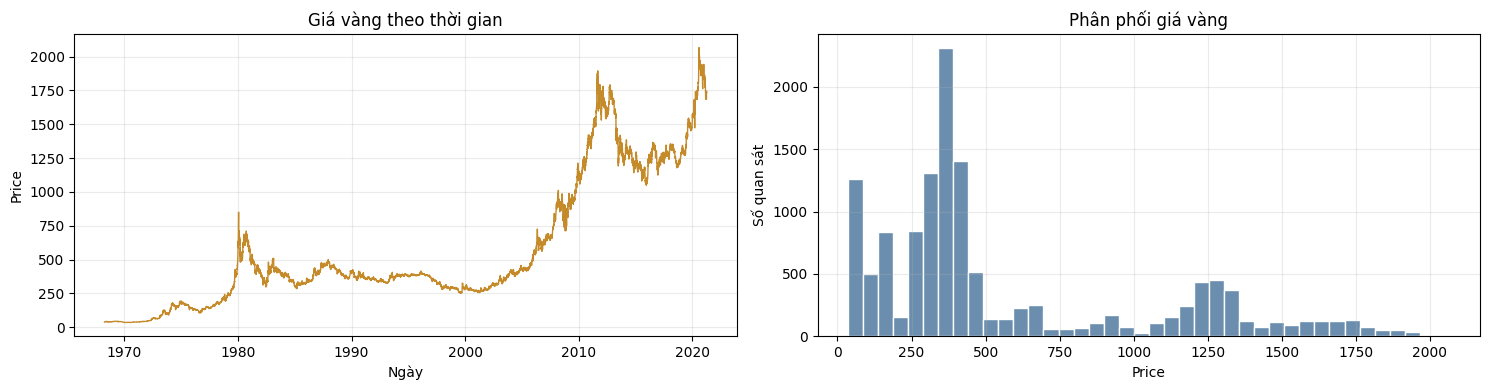

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].plot(df['date'], df['price'], color='#C58B2A', linewidth=1)
axes[0].set_title('Giá vàng theo thời gian')
axes[0].set_xlabel('Ngày')
axes[0].set_ylabel('Price')
axes[0].grid(alpha=0.25)

axes[1].hist(df['price'], bins=40, color='#6B8EAF', edgecolor='white')
axes[1].set_title('Phân phối giá vàng')
axes[1].set_xlabel('Price')
axes[1].set_ylabel('Số quan sát')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 3. Chia dữ liệu theo thời gian, chuẩn hóa và tạo cửa sổ

Không dùng `train_test_split(shuffle=True)` cho chuỗi thời gian. Scaler chỉ được `fit` trên train để tránh đưa thông tin của tương lai vào quá trình huấn luyện. Vì giá vàng tăng theo nhiều giai đoạn, notebook dùng `log1p(price)` trước Min-Max để giảm ảnh hưởng của phân phối lệch và giúp mô hình xử lý mức giá ở các năm sau ổn định hơn.

In [6]:
LOOKBACK = 30
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

raw_prices = df['price'].to_numpy(dtype=np.float32).reshape(-1, 1)
values = np.log1p(raw_prices)
n = len(values)
train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

scaler = MinMaxScaler()
scaler.fit(values[:train_end])
scaled_values = scaler.transform(values).astype(np.float32)
print('Biến đổi đầu vào: log1p(price) rồi Min-Max scaling')

def make_windows(data, lookback):
    X, y, target_positions = [], [], []
    for end in range(lookback, len(data)):
        X.append(data[end - lookback:end])
        y.append(data[end])
        target_positions.append(end)
    return (np.asarray(X, dtype=np.float32),
            np.asarray(y, dtype=np.float32),
            np.asarray(target_positions))

X, y, target_positions = make_windows(scaled_values, LOOKBACK)

train_mask = target_positions < train_end
val_mask = (target_positions >= train_end) & (target_positions < val_end)
test_mask = target_positions >= val_end

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print('Số quan sát:', n)
print('Train/validation/test:', len(X_train), len(X_val), len(X_test))
print('X_train:', X_train.shape)
print('y_train:', y_train.shape)
print('X_val:', X_val.shape)
print('X_test:', X_test.shape)

range_summary = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'start_date': [df.date.iloc[0], df.date.iloc[train_end], df.date.iloc[val_end]],
    'end_date': [df.date.iloc[train_end - 1], df.date.iloc[val_end - 1], df.date.iloc[-1]],
    'min_price': [df.price.iloc[:train_end].min(), df.price.iloc[train_end:val_end].min(), df.price.iloc[val_end:].min()],
    'max_price': [df.price.iloc[:train_end].max(), df.price.iloc[train_end:val_end].max(), df.price.iloc[val_end:].max()]
})
print('Phân phối giá theo từng tập:')
display(range_summary.round(3))

example_end = train_end
example = df.iloc[example_end - LOOKBACK:example_end][['date', 'price']].copy()
example['scaled_log_price'] = scaled_values[example_end - LOOKBACK:example_end, 0]
print('Một cửa sổ gồm 30 bước thời gian và mục tiêu là giá ở bước tiếp theo:')
display(example.head())
display(example.tail())
print('Target date:', df.iloc[example_end]['date'].date())
print('Target price:', df.iloc[example_end]['price'])

Biến đổi đầu vào: log1p(price) rồi Min-Max scaling
Số quan sát: 13320
Train/validation/test: 9294 1998 1998
X_train: (9294, 30, 1)
y_train: (9294, 1)
X_val: (1998, 30, 1)
X_test: (1998, 30, 1)
Phân phối giá theo từng tập:


,split,start_date,end_date,min_price,max_price
0,train,1968-04-01,2005-04-29,34.75,850.00
1,validation,2005-05-03,2013-04-19,414.45,1895.00
2,test,2013-04-22,2021-04-07,1049.40,2067.15


Một cửa sổ gồm 30 bước thời gian và mục tiêu là giá ở bước tiếp theo:


,date,price,scaled_log_price
9294,2005-03-17,438.60,0.791616
9295,2005-03-18,437.15,0.790574
9296,2005-03-21,432.70,0.787354
9297,2005-03-22,432.15,0.786953
9298,2005-03-23,426.15,0.782553


,date,price,scaled_log_price
9319,2005-04-25,432.90,0.787499
9320,2005-04-26,437.00,0.790466
9321,2005-04-27,434.35,0.788552
9322,2005-04-28,432.50,0.787208
9323,2005-04-29,435.70,0.789528


Target date: 2005-05-03
Target price: 427.9


## 4. Baseline dự báo

Baseline persistence dự đoán giá ngày tiếp theo bằng giá ở bước cuối của cửa sổ. Đây là mốc so sánh bắt buộc: RNN chỉ có ý nghĩa khi tốt hơn hoặc cung cấp phân tích bổ sung so với baseline.

In [7]:
def inverse_scale(array):
    log_price = scaler.inverse_transform(np.asarray(array).reshape(-1, 1)).ravel()
    return np.expm1(log_price)

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))) * 100
    return {'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape}

def directional_accuracy(previous, y_true, y_pred):
    actual_direction = np.sign(np.asarray(y_true).ravel() - np.asarray(previous).ravel())
    predicted_direction = np.sign(np.asarray(y_pred).ravel() - np.asarray(previous).ravel())
    return np.mean(actual_direction == predicted_direction) * 100

y_test_price = inverse_scale(y_test)
baseline_pred_price = inverse_scale(X_test[:, -1, :])
previous_test_price = baseline_pred_price.copy()
baseline_direction_previous = inverse_scale(X_test[:, -2, :])

baseline_result = regression_metrics(y_test_price, baseline_pred_price)
baseline_result['Direction accuracy (%)'] = directional_accuracy(
    baseline_direction_previous, y_test_price, baseline_pred_price
)

print('Baseline persistence:')
display(pd.DataFrame([baseline_result], index=['Persistence']).round(4))

Baseline persistence:


,MAE,RMSE,MAPE (%),Direction accuracy (%)
Persistence,9.2163,13.4675,0.6714,77.3273


## 5. Mô hình Simple RNN

Input của RNN có dạng `(batch, timesteps, features)`. Ở đây `features = 1` vì mỗi thời điểm chỉ dùng giá vàng. RNN đọc 30 giá trị trong cửa sổ và dùng hidden state ở bước cuối để dự đoán giá tiếp theo.

In [8]:
class SimpleRNNRegressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=32):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True,
            nonlinearity='tanh'
        )
        self.output_layer = nn.Linear(hidden_size, 1)

    def forward(self, x):
        sequence_output, _ = self.rnn(x)
        last_hidden = sequence_output[:, -1, :]
        return self.output_layer(last_hidden)

train_dataset = TensorDataset(
    torch.from_numpy(X_train), torch.from_numpy(y_train)
)
val_dataset = TensorDataset(
    torch.from_numpy(X_val), torch.from_numpy(y_val)
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

model = SimpleRNNRegressor(input_size=1, hidden_size=32).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)
print('Số tham số:', sum(parameter.numel() for parameter in model.parameters()))

SimpleRNNRegressor(
  (rnn): RNN(1, 32, batch_first=True)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)
Số tham số: 1153


In [9]:
def evaluate_loss(model, loader):
    model.eval()
    total_loss = 0.0
    total_count = 0
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            prediction = model(batch_x)
            loss = criterion(prediction, batch_y)
            total_loss += loss.item() * len(batch_x)
            total_count += len(batch_x)
    return total_loss / total_count

history = []
best_val_loss = float('inf')
best_state = None
patience = 5
wait = 0
epochs = 30

for epoch in range(1, epochs + 1):
    model.train()
    train_loss_sum = 0.0
    train_count = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        prediction = model(batch_x)
        loss = criterion(prediction, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss_sum += loss.item() * len(batch_x)
        train_count += len(batch_x)

    train_loss = train_loss_sum / train_count
    val_loss = evaluate_loss(model, val_loader)
    history.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss})

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1

    if epoch == 1 or epoch % 5 == 0:
        print(f'Epoch {epoch:02d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}')

    if wait >= patience:
        print(f'Early stopping tại epoch {epoch}')
        break

model.load_state_dict(best_state)
history_df = pd.DataFrame(history)
display(history_df.tail())

Epoch 01 | train_loss=0.011587 | val_loss=0.046442


Epoch 05 | train_loss=0.006748 | val_loss=0.013903


Epoch 10 | train_loss=0.000149 | val_loss=0.005683


Epoch 15 | train_loss=0.000195 | val_loss=0.003264


Epoch 20 | train_loss=0.000181 | val_loss=0.002521


Epoch 25 | train_loss=0.000172 | val_loss=0.002374


Early stopping tại epoch 28


,epoch,train_loss,val_loss
23,24,0.000175,0.002309
24,25,0.000172,0.002374
25,26,0.000167,0.002474
26,27,0.000161,0.002599
27,28,0.000157,0.002736


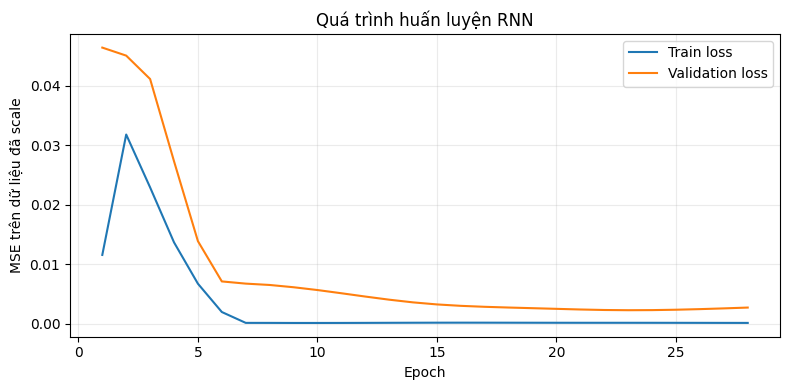

In [10]:
# Vẽ đường loss để đưa vào slide
plt.figure(figsize=(8, 4))
plt.plot(history_df['epoch'], history_df['train_loss'], label='Train loss')
plt.plot(history_df['epoch'], history_df['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('MSE trên dữ liệu đã scale')
plt.title('Quá trình huấn luyện RNN')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 6. Đánh giá trên tập test

MAE và RMSE đo sai số theo đơn vị giá. MAPE biểu diễn sai số tương đối. Direction accuracy cho biết mô hình đoán đúng hướng tăng/giảm so với giá cuối cùng trong cửa sổ.

In [11]:
model.eval()
with torch.no_grad():
    y_pred_scaled = model(torch.from_numpy(X_test).to(device)).cpu().numpy()

y_pred_price = inverse_scale(y_pred_scaled)
rnn_result = regression_metrics(y_test_price, y_pred_price)
rnn_result['Direction accuracy (%)'] = directional_accuracy(
    previous_test_price, y_test_price, y_pred_price
)

results = pd.DataFrame([baseline_result, rnn_result], index=['Persistence', 'Simple RNN'])
results = results[['MAE', 'RMSE', 'MAPE (%)', 'Direction accuracy (%)']]
print('So sánh baseline và RNN trên tập test:')
display(results.round(4))

So sánh baseline và RNN trên tập test:


,MAE,RMSE,MAPE (%),Direction accuracy (%)
Persistence,9.216300,13.467500,0.6714,77.3273
Simple RNN,236.113403,252.161194,16.9713,49.1992


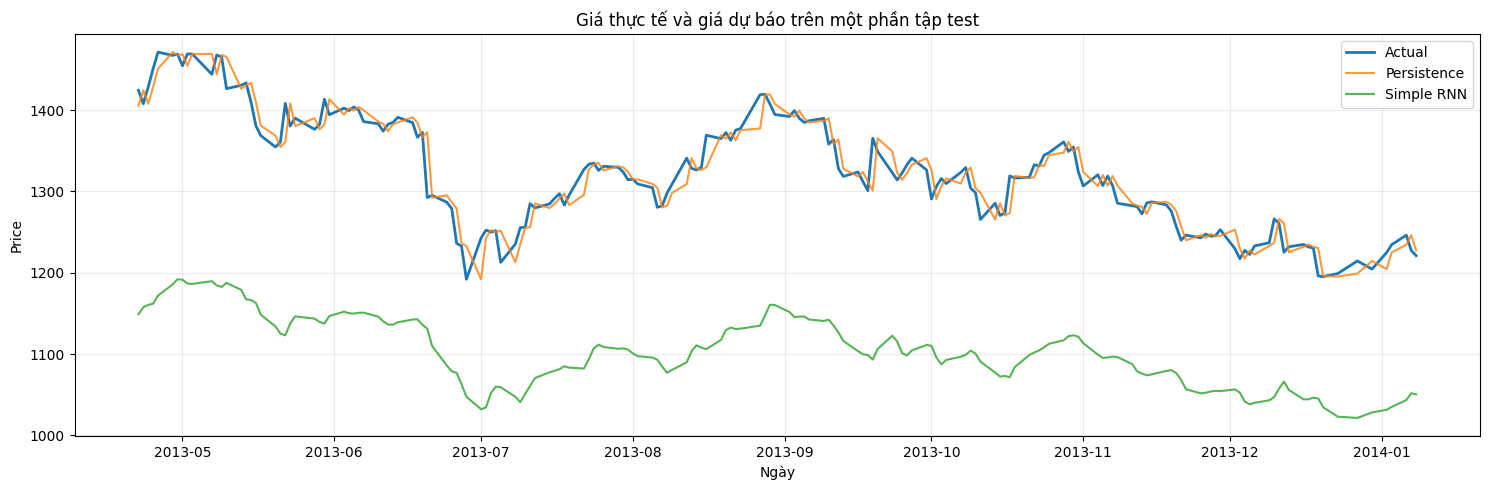

In [12]:
test_dates = df.iloc[target_positions[test_mask]]['date'].to_numpy()
plot_n = min(180, len(test_dates))

plt.figure(figsize=(15, 5))
plt.plot(test_dates[:plot_n], y_test_price[:plot_n], label='Actual', linewidth=2)
plt.plot(test_dates[:plot_n], baseline_pred_price[:plot_n], label='Persistence', alpha=0.8)
plt.plot(test_dates[:plot_n], y_pred_price[:plot_n], label='Simple RNN', alpha=0.8)
plt.title('Giá thực tế và giá dự báo trên một phần tập test')
plt.xlabel('Ngày')
plt.ylabel('Price')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

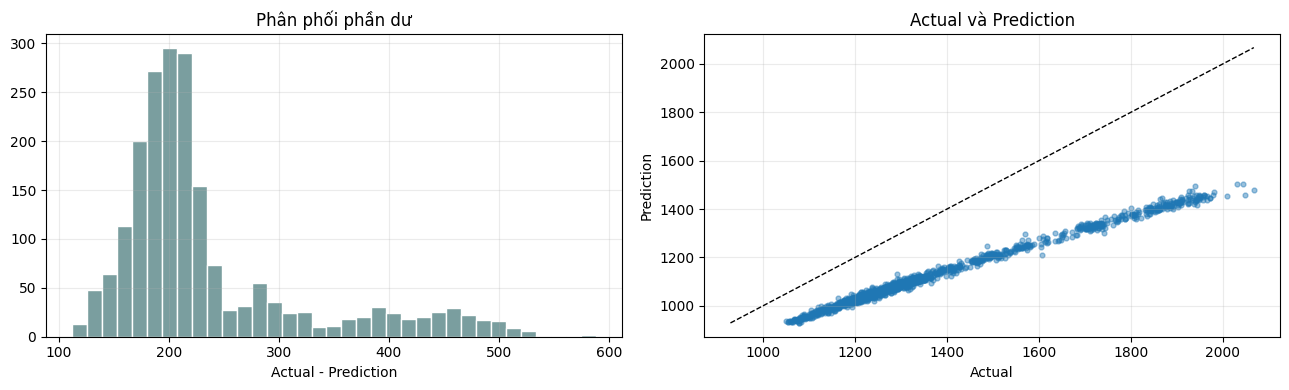

Bias phần dư trung bình: 236.1134
Độ lệch chuẩn phần dư: 88.5195
Tỷ lệ giá test cao hơn giá lớn nhất của train: 100.00%
Kết luận: RNN chưa vượt baseline theo MAE.
Giải thích: chuỗi giá có distribution shift và Simple RNN khó ngoại suy mức giá mới.
Hướng cải thiện: dự báo log-return, dùng cửa sổ gần đây hơn hoặc thử GRU/LSTM.


In [13]:
# Phân tích phần dư của RNN
residuals = y_test_price - y_pred_price

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(residuals, bins=35, color='#7A9E9F', edgecolor='white')
axes[0].set_title('Phân phối phần dư')
axes[0].set_xlabel('Actual - Prediction')
axes[0].grid(alpha=0.25)

axes[1].scatter(y_test_price, y_pred_price, s=12, alpha=0.45)
limits = [min(y_test_price.min(), y_pred_price.min()), max(y_test_price.max(), y_pred_price.max())]
axes[1].plot(limits, limits, '--', color='black', linewidth=1)
axes[1].set_title('Actual và Prediction')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Prediction')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f'Bias phần dư trung bình: {residuals.mean():.4f}')
print(f'Độ lệch chuẩn phần dư: {residuals.std():.4f}')

train_max_price = df.price.iloc[:train_end].max()
test_above_train_max = np.mean(df.price.iloc[val_end:].to_numpy() > train_max_price) * 100
print(f'Tỷ lệ giá test cao hơn giá lớn nhất của train: {test_above_train_max:.2f}%')

if rnn_result['MAE'] < baseline_result['MAE']:
    print('Kết luận: RNN tốt hơn baseline theo MAE trên tập test.')
else:
    print('Kết luận: RNN chưa vượt baseline theo MAE.')
    print('Giải thích: chuỗi giá có distribution shift và Simple RNN khó ngoại suy mức giá mới.')
    print('Hướng cải thiện: dự báo log-return, dùng cửa sổ gần đây hơn hoặc thử GRU/LSTM.')

## 7. Kết luận có thể đưa vào slide

- Chuỗi văn bản cần tokenizer, vocabulary, padding và embedding vì đầu vào ban đầu là các token rời rạc.
- Chuỗi giá vàng đã là số thực, nên pipeline phù hợp là làm sạch, sắp xếp theo thời gian, chuẩn hóa và tạo cửa sổ cố định.
- Với `LOOKBACK = 30`, mỗi mẫu có dạng `(30, 1)`: 30 bước thời gian và 1 đặc trưng giá.
- Tập train, validation và test được chia theo thứ tự thời gian. Scaler chỉ học từ train để tránh data leakage.
- Baseline persistence là mốc so sánh. Khi trình bày kết quả, cần báo cáo cả MAE/RMSE/MAPE và biểu đồ actual-prediction.
- Nếu RNN chưa tốt hơn persistence, không được che kết quả. Hãy kiểm tra distribution shift giữa train và test; đây là một kết luận phân tích hợp lệ.
- Với bài toán thực tế, có thể thử dự báo log-return, rút ngắn khoảng lịch sử hoặc dùng GRU/LSTM.

Các giá trị cụ thể của bảng `results` và các biểu đồ sau khi chạy notebook là phần nên chụp hoặc xuất trực tiếp vào slide.